In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import time
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from transformers import pipeline

## Importer le dataset

In [4]:
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\Amazon_Reviews.csv", engine="python")

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


Identifier les colonnes disponibles : 

In [5]:
df.columns

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')

Vérifier les colonnes manquantes : 

In [6]:
display(df.isnull().sum())
df = df.dropna()

Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

Taille totale du dataset : 

In [7]:
df.shape

(20946, 9)

## Étudier la répartition des classes 

In [8]:
df['Rating'].head(20)

0     Rated 1 out of 5 stars
1     Rated 1 out of 5 stars
2     Rated 1 out of 5 stars
3     Rated 1 out of 5 stars
4     Rated 1 out of 5 stars
5     Rated 1 out of 5 stars
6     Rated 1 out of 5 stars
7     Rated 5 out of 5 stars
8     Rated 1 out of 5 stars
9     Rated 5 out of 5 stars
10    Rated 5 out of 5 stars
11    Rated 1 out of 5 stars
12    Rated 2 out of 5 stars
13    Rated 1 out of 5 stars
14    Rated 1 out of 5 stars
15    Rated 1 out of 5 stars
16    Rated 1 out of 5 stars
17    Rated 1 out of 5 stars
18    Rated 1 out of 5 stars
19    Rated 2 out of 5 stars
Name: Rating, dtype: object

In [9]:
df = df[['Review Text', 'Rating']].dropna()

df = df.rename(columns={
    'Review Text': 'review_text'
})

df.head()

,review_text,Rating
0,"I registered on the website, tried to order a ...",Rated 1 out of 5 stars
1,Had multiple orders one turned up and driver h...,Rated 1 out of 5 stars
2,I informed these reprobates that I WOULD NOT B...,Rated 1 out of 5 stars
3,I have bought from Amazon before and no proble...,Rated 1 out of 5 stars
4,If I could give a lower rate I would! I cancel...,Rated 1 out of 5 stars


Convertir les Ratings en nombre : 

In [10]:
df['rating_num'] = df['Rating'].astype(str).str.extract(r'(\d+)')
df['rating_num'] = pd.to_numeric(df['rating_num'], errors='coerce')
df = df.dropna(subset=['rating_num'])

## Créer la colonne des sentiments 

In [11]:
df = df[df['rating_num'] != 3]

df['sentiment'] = df['rating_num'].apply(
    lambda x: 'positive' if x > 3 else 'negative'
)
df.head()

,review_text,Rating,rating_num,sentiment
0,"I registered on the website, tried to order a ...",Rated 1 out of 5 stars,1,negative
1,Had multiple orders one turned up and driver h...,Rated 1 out of 5 stars,1,negative
2,I informed these reprobates that I WOULD NOT B...,Rated 1 out of 5 stars,1,negative
3,I have bought from Amazon before and no proble...,Rated 1 out of 5 stars,1,negative
4,If I could give a lower rate I would! I cancel...,Rated 1 out of 5 stars,1,negative


In [12]:
print(df['sentiment'].value_counts())
print(df.shape)

sentiment
negative    14347
positive     5725
Name: count, dtype: int64
(20072, 4)


---
## Prétraitement des données 
---

Installer et importer NLTK

In [13]:
# NLTK déjà importé dans la cellule d'imports globaux ci-dessus

## Préparer les stopwords 

In [14]:
stop_words = set(stopwords.words('english'))

negation_words = {"not", "no", "never", "n't"}

stop_words = stop_words - negation_words

Créer la fonction de nettoyage 

In [15]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    
    text = re.sub(r'\d+', '', text)
    
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    tokens = nltk.word_tokenize(text)
    
    tokens = [word for word in tokens if word not in stop_words]
    
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(tokens)

Appliquer le nettoyage 

In [16]:
df['clean_review'] = df['review_text'].apply(clean_text)

comparer avant/après nettoyage

In [17]:
df[['review_text', 'clean_review', 'sentiment']].head()

,review_text,clean_review,sentiment
0,"I registered on the website, tried to order a ...",registered website tried order laptop entered ...,negative
1,Had multiple orders one turned up and driver h...,multiple order one turned driver phone no door...,negative
2,I informed these reprobates that I WOULD NOT B...,informed reprobate would not going visit sick ...,negative
3,I have bought from Amazon before and no proble...,bought amazon no problem happy service price a...,negative
4,If I could give a lower rate I would! I cancel...,could give lower rate would cancelled amazon p...,negative


In [18]:
df['clean_review'].isnull().sum()

np.int64(0)

In [19]:
(df['clean_review'] == '').sum()

np.int64(0)

In [20]:
df = df[df['clean_review'] != '']
df.shape

(20072, 5)

---
## Représentation Bag of Words
---

In [21]:
df[['clean_review', 'sentiment']].head()

,clean_review,sentiment
0,registered website tried order laptop entered ...,negative
1,multiple order one turned driver phone no door...,negative
2,informed reprobate would not going visit sick ...,negative
3,bought amazon no problem happy service price a...,negative
4,could give lower rate would cancelled amazon p...,negative


In [22]:
# Imports déjà effectués dans la cellule d'initialisation

Créer la representation Bag of Words 

In [23]:
bow_vectorizer = CountVectorizer(max_features=5000)

X_bow = bow_vectorizer.fit_transform(df['clean_review'])
print("Dimensions de la matrice Bag of Words :", X_bow.shape)

Dimensions de la matrice Bag of Words : (20072, 5000)


Voir les mots de vocabulaire : 

In [24]:
words = bow_vectorizer.get_feature_names_out()

print(words[:50])

['abandoned' 'ability' 'able' 'abroad' 'abrupt' 'abruptly' 'absolute'
 'absolutely' 'absurd' 'abuse' 'abused' 'abusing' 'abusive' 'abysmal'
 'abyss' 'ac' 'acc' 'accent' 'accept' 'acceptable' 'accepted' 'accepting'
 'access' 'accessed' 'accessible' 'accessing' 'accessory' 'accident'
 'accidentally' 'accommodate' 'according' 'account' 'accountability'
 'accountable' 'accounti' 'accountthe' 'acct' 'accuracy' 'accurate'
 'accurately' 'accusation' 'accuse' 'accused' 'accusing' 'achieve'
 'achieved' 'acknowledge' 'acknowledged' 'across' 'act']


identifier les mots les plus fréquents

In [25]:
word_counts = np.asarray(X_bow.sum(axis=0)).flatten()

bow_freq = pd.DataFrame({
    'word': words,
    'count': word_counts
})

bow_freq = bow_freq.sort_values(by='count', ascending=False)

bow_freq.head(20)

,word,count
169,amazon,29500
2925,not,17178
1077,customer,12055
3930,service,11151
2372,item,9387
1174,delivery,8105
4485,time,7960
2909,no,7739
1107,day,7627
3017,order,7549


visualiser les mots les plus fréquents

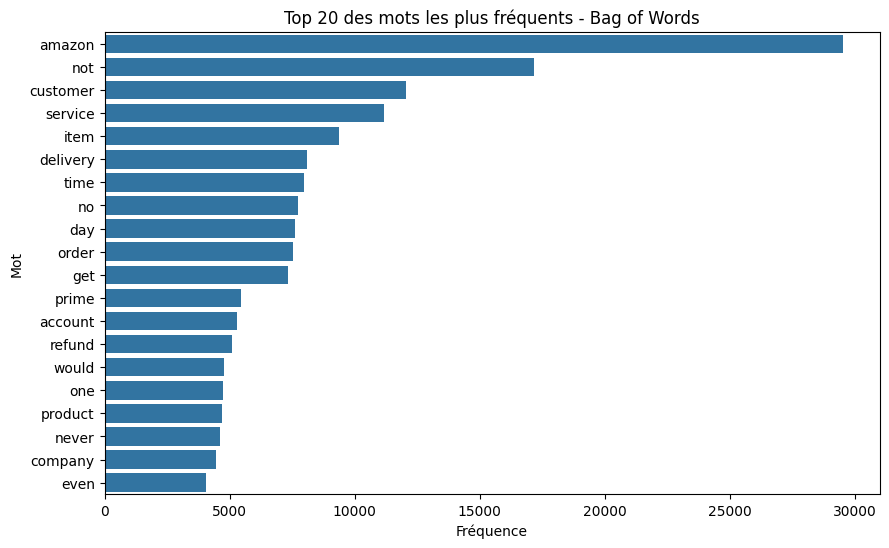

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=bow_freq.head(20),
    x='count',
    y='word'
)

plt.title("Top 20 des mots les plus fréquents - Bag of Words")
plt.xlabel("Fréquence")
plt.ylabel("Mot")
plt.show()

---
## Représentation TF-IDF.
---

In [27]:
# Imports déjà effectués dans la cellule d'initialisation

créer la matrice TF-IDF

In [28]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_review'])
print("Dimensions de la matrice TF-IDF :", X_tfidf.shape)

Dimensions de la matrice TF-IDF : (20072, 5000)


Afficher les termes du vocabulaire 

In [29]:
terms = tfidf_vectorizer.get_feature_names_out()
print(terms[:50])

['ability' 'able' 'able get' 'able help' 'absolute' 'absolute joke'
 'absolutely' 'absolutely disgusting' 'absolutely no' 'absolutely nothing'
 'absolutely ridiculous' 'absolutely shocking' 'absolutely terrible'
 'absolutely useless' 'absurd' 'abuse' 'abusive' 'abysmal' 'accent'
 'accept' 'acceptable' 'accepted' 'accepting' 'access' 'access account'
 'accessory' 'accident' 'accidentally' 'according' 'according amazon'
 'account' 'account amazon' 'account blocked' 'account called'
 'account cant' 'account closed' 'account due' 'account even'
 'account get' 'account got' 'account hacked' 'account hold'
 'account holder' 'account locked' 'account never' 'account no'
 'account not' 'account order' 'account said' 'account specialist']


identifier les termes les plus discriminants

In [30]:
tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).flatten()

tfidf_df = pd.DataFrame({
    'term': terms,
    'score': tfidf_scores
})

tfidf_df = tfidf_df.sort_values(by='score', ascending=False)

tfidf_df.head(20)

,term,score
158,amazon,0.052794
2839,not,0.039010
3963,service,0.031751
1082,customer,0.030440
1230,delivery,0.026776
2228,item,0.026254
4474,time,0.023243
3066,order,0.022760
1117,day,0.022385
1094,customer service,0.022325


visualiser les meilleurs termes TF-IDF

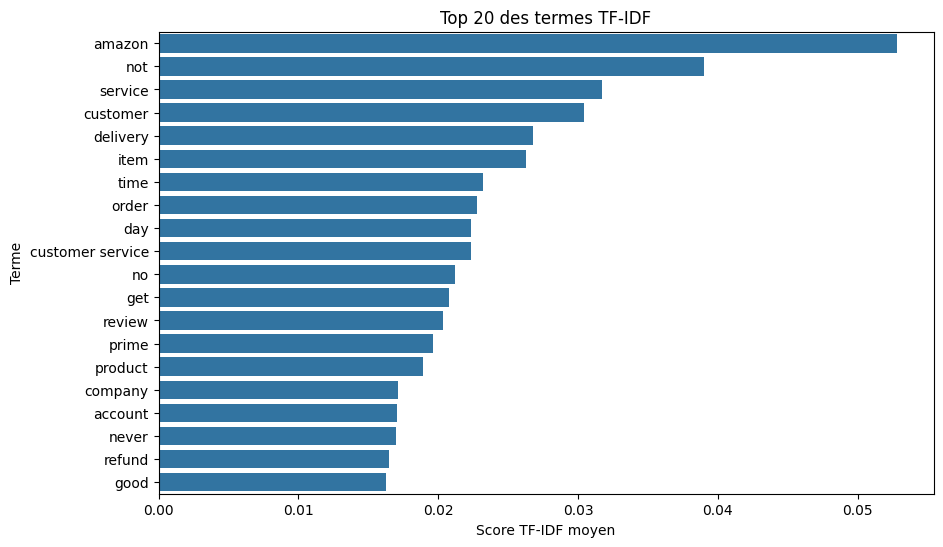

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=tfidf_df.head(20),
    x='score',
    y='term'
)

plt.title("Top 20 des termes TF-IDF")
plt.xlabel("Score TF-IDF moyen")
plt.ylabel("Terme")
plt.show()

---
## Classification Classique
---

vérifier les données disponibles

In [32]:
df[['clean_review', 'sentiment']].head()

,clean_review,sentiment
0,registered website tried order laptop entered ...,negative
1,multiple order one turned driver phone no door...,negative
2,informed reprobate would not going visit sick ...,negative
3,bought amazon no problem happy service price a...,negative
4,could give lower rate would cancelled amazon p...,negative


Créer la variable cible

In [33]:
df['label'] = df['sentiment'].map({
    'negative': 0,
    'positive': 1
})
df[['sentiment', 'label']].head()

,sentiment,label
0,negative,0
1,negative,0
2,negative,0
3,negative,0
4,negative,0


Vérifie aussi qu'il n'y a pas de valeurs vides : 

In [34]:
df['label'].isnull().sum()

np.int64(0)

Si le résultat est supérieur à 0, exécute :

In [35]:
df = df.dropna(subset=['label'])

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

import pandas as pd
import time

X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(
    X_bow,
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

Créer une fonction d'évaluation 

In [37]:
results = []

def evaluate_model(model, X_train, X_test, y_train, y_test, representation, model_name):
    start_time = time.time()
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    execution_time = time.time() - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        'Representation': representation,
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'Execution Time': execution_time
    })
    
    print("====================================================")
    print(representation, "+", model_name)
    print("====================================================")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)
    print("Temps    :", execution_time, "secondes")
    print()
    print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))
    
    return y_pred

tester les modèles avec Bag of Words

In [38]:
nb_bow = MultinomialNB()

pred_nb_bow = evaluate_model(
    nb_bow,
    X_train_bow,
    X_test_bow,
    y_train_bow,
    y_test_bow,
    "Bag of Words",
    "Naive Bayes"
)

Bag of Words + Naive Bayes
Accuracy : 0.9168119551681195
Precision: 0.82414068745004
Recall   : 0.9004366812227074
F1-score : 0.8606010016694491
Temps    : 0.010594844818115234 secondes

              precision    recall  f1-score   support

    negative       0.96      0.92      0.94      2870
    positive       0.82      0.90      0.86      1145

    accuracy                           0.92      4015
   macro avg       0.89      0.91      0.90      4015
weighted avg       0.92      0.92      0.92      4015



Bag of Words + Logistic Regression

In [39]:
lr_bow = LogisticRegression(max_iter=1000)

pred_lr_bow = evaluate_model(
    lr_bow,
    X_train_bow,
    X_test_bow,
    y_train_bow,
    y_test_bow,
    "Bag of Words",
    "Logistic Regression"
)

Bag of Words + Logistic Regression
Accuracy : 0.9270236612702366
Precision: 0.8509060955518946
Recall   : 0.9021834061135371
F1-score : 0.8757948283170836
Temps    : 0.19305920600891113 secondes

              precision    recall  f1-score   support

    negative       0.96      0.94      0.95      2870
    positive       0.85      0.90      0.88      1145

    accuracy                           0.93      4015
   macro avg       0.91      0.92      0.91      4015
weighted avg       0.93      0.93      0.93      4015



Bag of Words + SVM

In [40]:
svm_bow = LinearSVC()

pred_svm_bow = evaluate_model(
    svm_bow,
    X_train_bow,
    X_test_bow,
    y_train_bow,
    y_test_bow,
    "Bag of Words",
    "SVM"
)

Bag of Words + SVM
Accuracy : 0.9188044831880449
Precision: 0.821681068342498
Recall   : 0.9135371179039301
F1-score : 0.8651778329197684
Temps    : 0.8173925876617432 secondes

              precision    recall  f1-score   support

    negative       0.96      0.92      0.94      2870
    positive       0.82      0.91      0.87      1145

    accuracy                           0.92      4015
   macro avg       0.89      0.92      0.90      4015
weighted avg       0.92      0.92      0.92      4015



tester les modèles avec TF-IDF + Naive Bayes 

In [41]:
nb_tfidf = MultinomialNB()

pred_nb_tfidf = evaluate_model(
    nb_tfidf,
    X_train_tfidf,
    X_test_tfidf,
    y_train_tfidf,
    y_test_tfidf,
    "TF-IDF",
    "Naive Bayes"
)

TF-IDF + Naive Bayes
Accuracy : 0.9198007471980074
Precision: 0.904621435594887
Recall   : 0.8034934497816594
F1-score : 0.851063829787234
Temps    : 0.008759498596191406 secondes

              precision    recall  f1-score   support

    negative       0.92      0.97      0.95      2870
    positive       0.90      0.80      0.85      1145

    accuracy                           0.92      4015
   macro avg       0.91      0.88      0.90      4015
weighted avg       0.92      0.92      0.92      4015



TF-IDF + Logistic Regression

In [42]:
lr_tfidf = LogisticRegression(max_iter=1000)

pred_lr_tfidf = evaluate_model(
    lr_tfidf,
    X_train_tfidf,
    X_test_tfidf,
    y_train_tfidf,
    y_test_tfidf,
    "TF-IDF",
    "Logistic Regression"
)

TF-IDF + Logistic Regression
Accuracy : 0.9325031133250311
Precision: 0.908411214953271
Recall   : 0.8489082969432314
F1-score : 0.8776523702031602
Temps    : 0.0801858901977539 secondes

              precision    recall  f1-score   support

    negative       0.94      0.97      0.95      2870
    positive       0.91      0.85      0.88      1145

    accuracy                           0.93      4015
   macro avg       0.92      0.91      0.92      4015
weighted avg       0.93      0.93      0.93      4015



TF-IDF + SVM

In [43]:
svm_tfidf = LinearSVC()

pred_svm_tfidf = evaluate_model(
    svm_tfidf,
    X_train_tfidf,
    X_test_tfidf,
    y_train_tfidf,
    y_test_tfidf,
    "TF-IDF",
    "SVM"
)

TF-IDF + SVM
Accuracy : 0.9367372353673723
Precision: 0.8877284595300261
Recall   : 0.8908296943231441
F1-score : 0.8892763731473409
Temps    : 0.08097052574157715 secondes

              precision    recall  f1-score   support

    negative       0.96      0.96      0.96      2870
    positive       0.89      0.89      0.89      1145

    accuracy                           0.94      4015
   macro avg       0.92      0.92      0.92      4015
weighted avg       0.94      0.94      0.94      4015



afficher le tableau final des résultats

In [44]:
results_df = pd.DataFrame(results)

results_df

,Representation,Model,Accuracy,Precision,Recall,F1-score,Execution Time
0,Bag of Words,Naive Bayes,0.916812,0.824141,0.900437,0.860601,0.010595
1,Bag of Words,Logistic Regression,0.927024,0.850906,0.902183,0.875795,0.193059
2,Bag of Words,SVM,0.918804,0.821681,0.913537,0.865178,0.817393
3,TF-IDF,Naive Bayes,0.919801,0.904621,0.803493,0.851064,0.008759
4,TF-IDF,Logistic Regression,0.932503,0.908411,0.848908,0.877652,0.080186
5,TF-IDF,SVM,0.936737,0.887728,0.890830,0.889276,0.080971


trier du meilleur au moins bon selon le F1-Score 

In [45]:
results_df.sort_values(by='F1-score', ascending=False)

,Representation,Model,Accuracy,Precision,Recall,F1-score,Execution Time
5,TF-IDF,SVM,0.936737,0.887728,0.890830,0.889276,0.080971
4,TF-IDF,Logistic Regression,0.932503,0.908411,0.848908,0.877652,0.080186
1,Bag of Words,Logistic Regression,0.927024,0.850906,0.902183,0.875795,0.193059
2,Bag of Words,SVM,0.918804,0.821681,0.913537,0.865178,0.817393
0,Bag of Words,Naive Bayes,0.916812,0.824141,0.900437,0.860601,0.010595
3,TF-IDF,Naive Bayes,0.919801,0.904621,0.803493,0.851064,0.008759


---
## Analyse Contextuelle avec BERT
---

In [46]:
# Imports déjà effectués dans la cellule d'initialisation

préparer un échantillon du dataset

In [47]:
df_bert = df.sample(500, random_state=42).copy()

verifier les colonnes nécessaires 

In [48]:
df_bert[['review_text', 'sentiment', 'label']].head()

,review_text,sentiment,label
19218,Amazon is the best place to shop online. Perio...,positive,1
9596,"My daughter ordered me a laptop from LAPTOPS, ...",negative,0
15522,The live chat is no longer humans . Now we eit...,negative,0
18471,Never faced any problems shopping there. I'm n...,positive,1
12594,"Amzon do not recognice genuine passwords, send...",negative,0


charger le modèle BERT

In [49]:
bert_classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4821.68it/s]


Test du modèle BERT

In [50]:
bert_classifier("This product is very good")


[{'label': 'POSITIVE', 'score': 0.9998717308044434}]

In [51]:
bert_classifier("This product is not good")

[{'label': 'NEGATIVE', 'score': 0.9998018145561218}]

appliquer BERT sur le dataset

In [52]:
start_time = time.time()

texts = [str(t)[:512] for t in df_bert['review_text']]

raw_preds = bert_classifier(texts, batch_size=16, truncation=True)

bert_predictions = [1 if r['label'] == 'POSITIVE' else 0 for r in raw_preds]

bert_time = time.time() - start_time

évaluer BERT

In [53]:
y_true_bert = df_bert['label']

bert_accuracy = accuracy_score(y_true_bert, bert_predictions)
bert_precision = precision_score(y_true_bert, bert_predictions, zero_division=0)
bert_recall = recall_score(y_true_bert, bert_predictions, zero_division=0)
bert_f1 = f1_score(y_true_bert, bert_predictions, zero_division=0)

print("Accuracy :", bert_accuracy)
print("Precision:", bert_precision)
print("Recall   :", bert_recall)
print("F1-score :", bert_f1)
print("Temps d'exécution :", bert_time, "secondes")

print(classification_report(
    y_true_bert,
    bert_predictions,
    target_names=['negative', 'positive']
))

Accuracy : 0.922
Precision: 0.9652173913043478
Recall   : 0.7602739726027398
F1-score : 0.8505747126436781
Temps d'exécution : 19.463746309280396 secondes
              precision    recall  f1-score   support

    negative       0.91      0.99      0.95       354
    positive       0.97      0.76      0.85       146

    accuracy                           0.92       500
   macro avg       0.94      0.87      0.90       500
weighted avg       0.93      0.92      0.92       500



ajouter BERT au tableau des résultats

In [54]:
results.append({
    'Representation': 'BERT',
    'Model': 'DistilBERT',
    'Accuracy': bert_accuracy,
    'Precision': bert_precision,
    'Recall': bert_recall,
    'F1-score': bert_f1,
    'Execution Time': bert_time
})

results_df = pd.DataFrame(results)
results_df.sort_values(by='F1-score', ascending=False)

,Representation,Model,Accuracy,Precision,Recall,F1-score,Execution Time
5,TF-IDF,SVM,0.936737,0.887728,0.890830,0.889276,0.080971
4,TF-IDF,Logistic Regression,0.932503,0.908411,0.848908,0.877652,0.080186
1,Bag of Words,Logistic Regression,0.927024,0.850906,0.902183,0.875795,0.193059
2,Bag of Words,SVM,0.918804,0.821681,0.913537,0.865178,0.817393
0,Bag of Words,Naive Bayes,0.916812,0.824141,0.900437,0.860601,0.010595
3,TF-IDF,Naive Bayes,0.919801,0.904621,0.803493,0.851064,0.008759
6,BERT,DistilBERT,0.922000,0.965217,0.760274,0.850575,19.463746


--- 
## Visualisation 
---

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from wordcloud import WordCloud

print(len(y_test_tfidf))
print(len(pred_svm_tfidf))

4015
4015


Matrice de confusion 

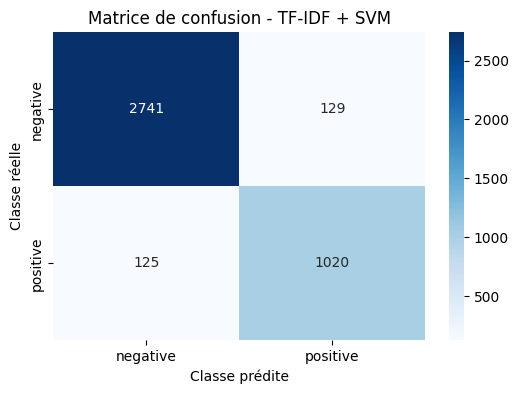

In [56]:
cm = confusion_matrix(y_test_tfidf, pred_svm_tfidf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'positive'],
    yticklabels=['negative', 'positive']
)

plt.title("Matrice de confusion - TF-IDF + SVM")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

Histogramme des sentiments

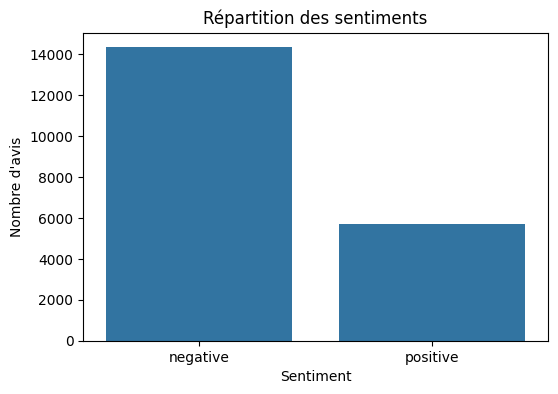

In [57]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='sentiment'
)

plt.title("Répartition des sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d'avis")
plt.show()

L’histogramme montre la répartition des avis positifs et négatifs dans le dataset. Il permet de vérifier si les classes sont équilibrées ou si une classe est dominante.

## WordCloud des avis positifs

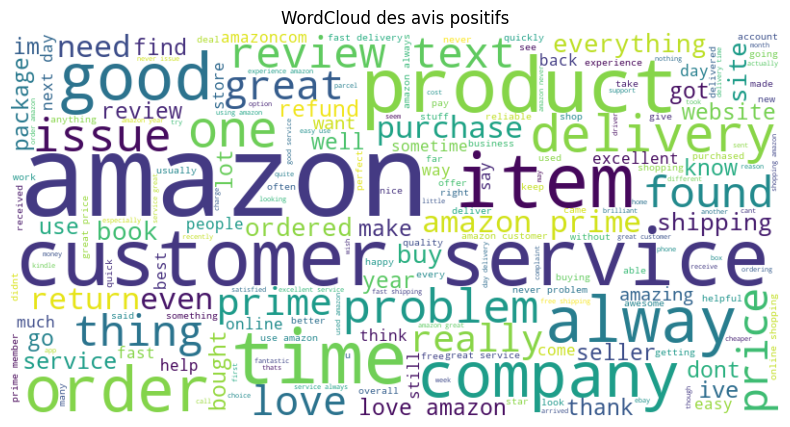

In [58]:
positive_text = " ".join(
    df[df['sentiment'] == 'positive']['clean_review'].astype(str)
)

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud des avis positifs")
plt.show()

## WordCloud des avis négatifs

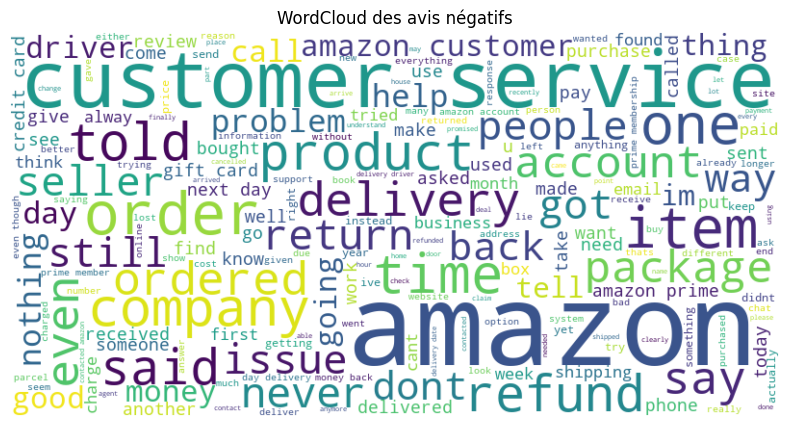

In [59]:
negative_text = " ".join(
    df[df['sentiment'] == 'negative']['clean_review'].astype(str)
)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud des avis négatifs")
plt.show()

In [60]:
# Sauvegarder le vectorizer TF-IDF
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

# Sauvegarder le modèle SVM
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(svm_tfidf, f)

print("Modèles sauvegardés : tfidf_vectorizer.pkl et sentiment_model.pkl")

Modèles sauvegardés : tfidf_vectorizer.pkl et sentiment_model.pkl
